1. Load the Iris dataset using scikit-learn, train a DecisionTreeClassifier, and plot the resulting decision tree using plot_tree().


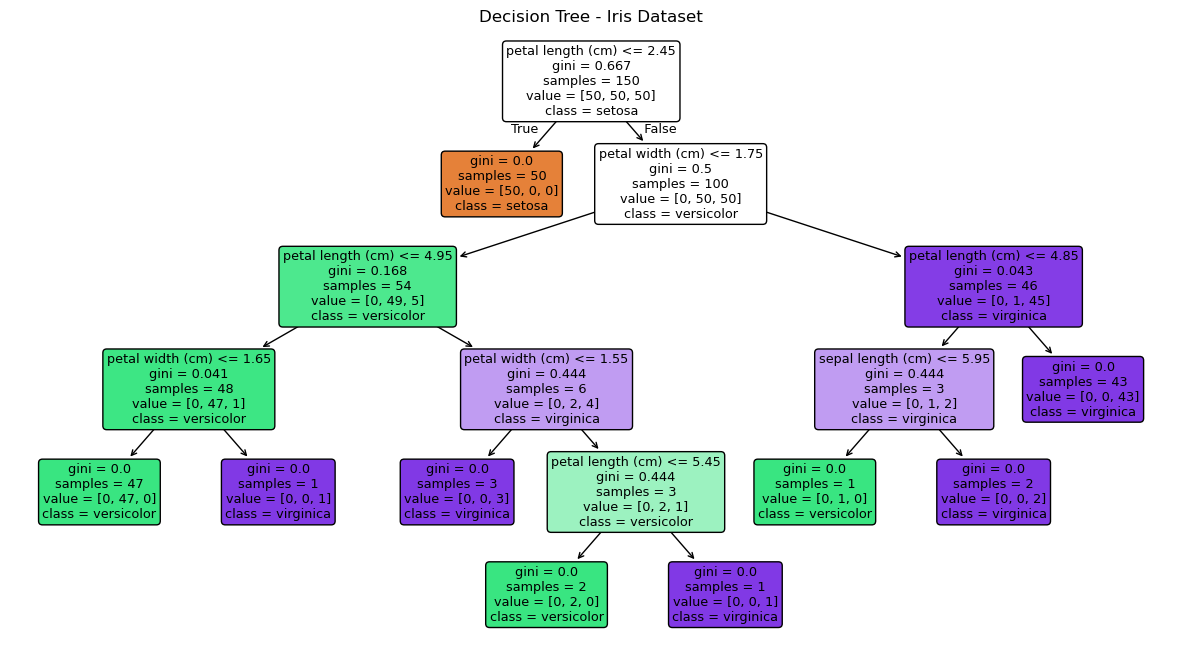

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

iris = load_iris()

X = iris.data
y = iris.target

model = DecisionTreeClassifier(random_state=42)
model.fit(X, y)

plt.figure(figsize=(15, 8))
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.title("Decision Tree - Iris Dataset")
plt.show()

2. Change the splitting criterion of your DecisionTreeClassifier from 'gini' to 'entropy' and compare the accuracy scores for both on the same dataset.<br><br><em><strong>Hint:</strong> Use the 'criterion' parameter when initializing the classifier.</em>


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

gini_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

gini_model.fit(X_train, y_train)

gini_pred = gini_model.predict(X_test)

gini_acc = accuracy_score(y_test, gini_pred)

entropy_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

entropy_model.fit(X_train, y_train)

entropy_pred = entropy_model.predict(X_test)

entropy_acc = accuracy_score(y_test, entropy_pred)

print("Gini Accuracy :", gini_acc)
print("Entropy Accuracy :", entropy_acc)

Gini Accuracy : 1.0
Entropy Accuracy : 0.9777777777777777


3. Limit the maximum depth of your decision tree to 2 and visualize the new tree structure. Observe and briefly describe how the tree's decisions have changed compared to the full-depth tree.


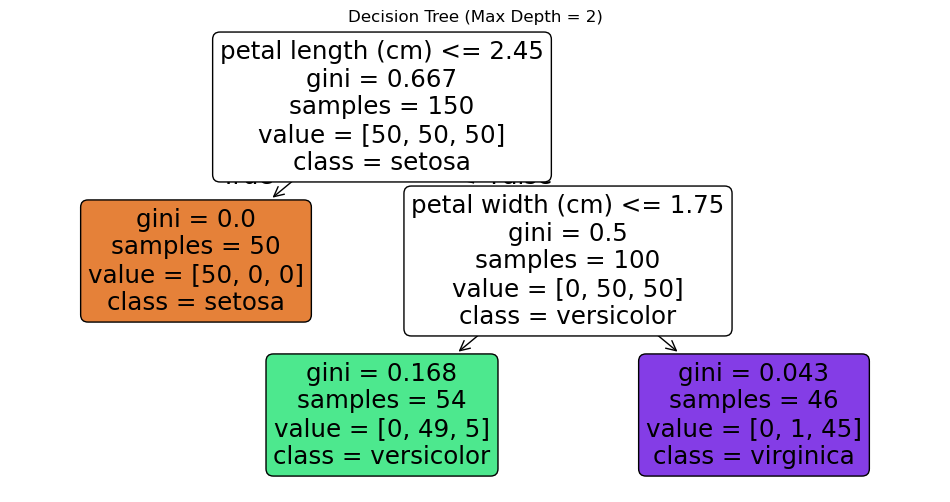

In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree_depth2 = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

tree_depth2.fit(X, y)

plt.figure(figsize=(12, 6))

plot_tree(
    tree_depth2,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)

plt.title("Decision Tree (Max Depth = 2)")
plt.show()

4. Use the feature_importances_ attribute of your trained DecisionTreeClassifier to display the importance score for each feature in the Iris dataset. Sort and print the features from most to least important.


In [4]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

             Feature  Importance
2  petal length (cm)    0.564056
3   petal width (cm)    0.422611
0  sepal length (cm)    0.013333
1   sepal width (cm)    0.000000


5. Pick any dataset from Kaggle (such as a simple food delivery ratings or IPL match stats CSV), train a decision tree, and interpret the first three splits in your own words — explain which feature and value the tree is using at each split and why it might help classification.<br><br><em><strong>Hint:</strong> Use plot_tree() with feature_names and read the conditions shown at each node.</em>

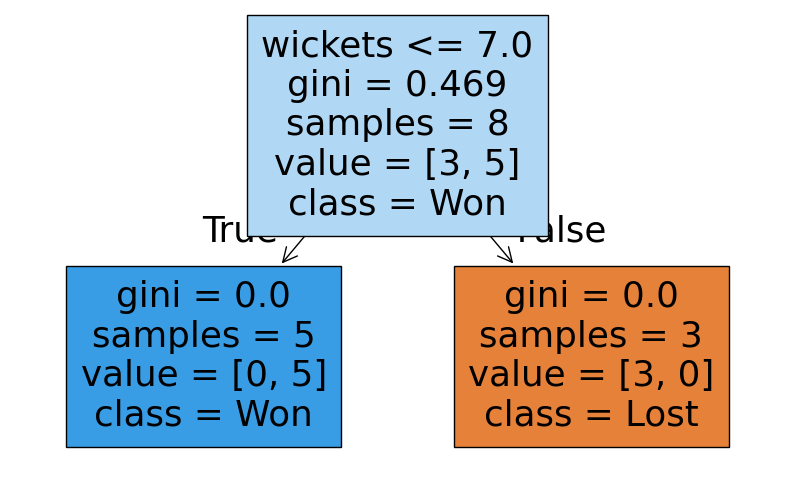

In [5]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

ipl = pd.DataFrame({
    "runs":[180,150,210,130,175,190,145,220],
    "wickets":[5,8,3,9,6,4,10,2],
    "overs":[20,20,20,20,20,20,20,20],
    "won":[1,0,1,0,1,1,0,1]
})

X = ipl[["runs","wickets","overs"]]
y = ipl["won"]

model = DecisionTreeClassifier(random_state=42)
model.fit(X, y)

plt.figure(figsize=(10,6))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Lost","Won"],
    filled=True
)

plt.show()